# 🌿 Plant Disease Detection using EfficientNetB0

## 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory

## 2. Dataset Exploration

In [2]:

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mohitsingh1804
/kaggle/input/datasets/mohitsingh1804/plantvillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Tomato___Late_blight
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Tomato___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Grape___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Orange___Haunglongbing_(Citrus_greening)
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Squash___Powdery_mildew
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Potato___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Corn_(maize)___Northern_Leaf_Blight
/kaggle/

In [3]:
train_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train"
val_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val"

In [4]:

train_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train"
val_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val"

classes = sorted(os.listdir(train_dir))

print(f"Number of classes: {len(classes)}")
print("\nClasses:\n")

for cls in classes:
    print(cls)

Number of classes: 38

Classes:

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus


In [5]:
import pandas as pd

train_counts = []

for cls in classes:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    train_counts.append(count)

df = pd.DataFrame({
    "Class": classes,
    "Training Images": train_counts
})

df

,Class,Training Images
0,Apple___Apple_scab,504
1,Apple___Black_rot,496
2,Apple___Cedar_apple_rust,220
3,Apple___healthy,1316
4,Blueberry___healthy,1202
5,Cherry_(including_sour)___Powdery_mildew,842
6,Cherry_(including_sour)___healthy,684
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410
8,Corn_(maize)___Common_rust_,953
9,Corn_(maize)___Northern_Leaf_Blight,788


## 3. Data Loading and Preprocessing
In this section, we load the training and validation datasets, resize all images to a fixed size, create batches for efficient training, and prepare the data for the deep learning model.

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 43444 files belonging to 38 classes.


I0000 00:00:1784280632.253597      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784280632.256611      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 10861 files belonging to 38 classes.


### Visualizing a Batch of Training Images
To verify that the dataset has been loaded correctly, we display a batch of training images along with their corresponding class labels.

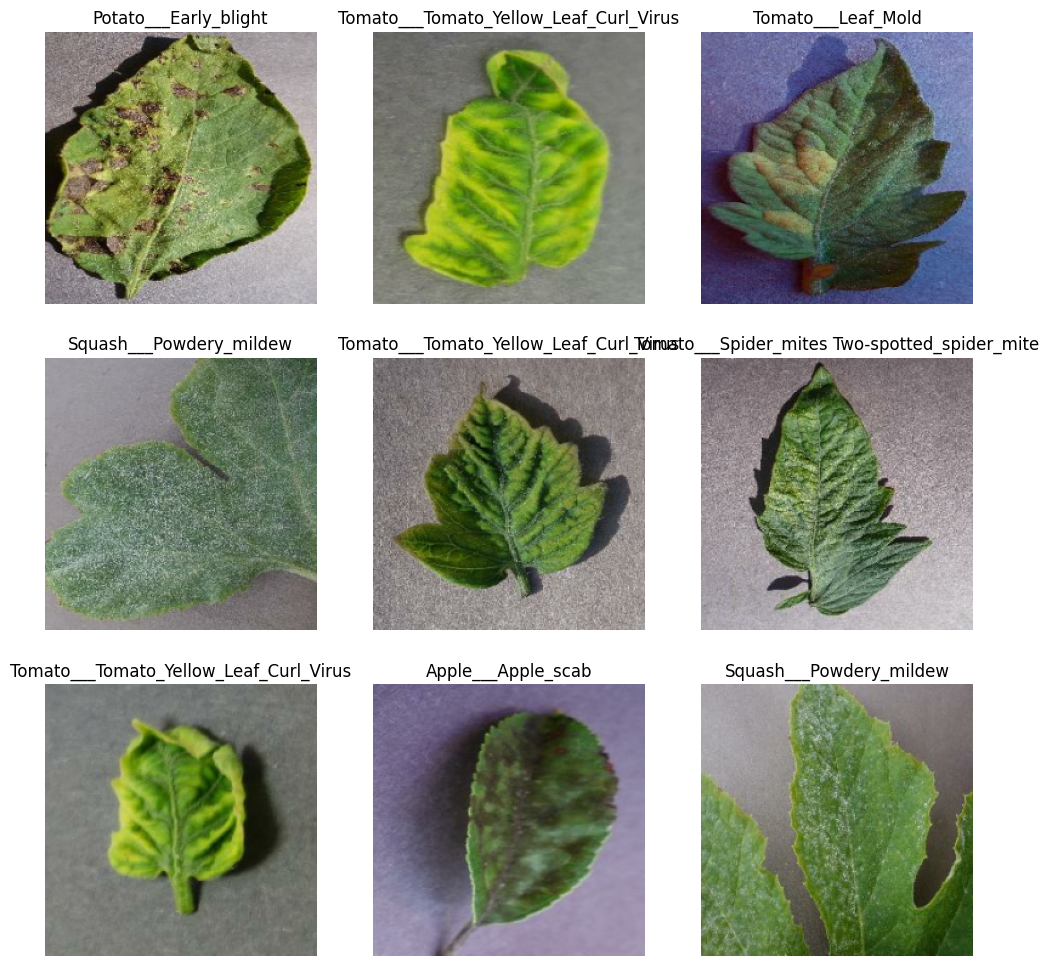

In [9]:
plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 4. Data Augmentation and Preprocessing

Data augmentation is used to artificially increase the diversity of the training dataset by applying random transformations such as flipping, rotation, and zooming. This helps reduce overfitting and improves the model's ability to generalize to unseen images.

Additionally, the pixel values are preprocessed according to the requirements of the EfficientNetB0 model.

In [12]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

### Performance Optimization

To improve training efficiency, TensorFlow's `prefetch()` method is used. This allows the model to prepare the next batch of data while the current batch is being processed, resulting in faster training.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

## 5. Building the EfficientNetB0 Model

In this section, we use EfficientNetB0 as the base model with pre-trained ImageNet weights. Transfer learning allows the model to leverage features learned from millions of images, reducing training time and improving classification performance.

Initially, the base model is frozen so that only the newly added classification layers are trained.

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Creating the Classification Head

The pretrained EfficientNetB0 model is combined with additional layers, including data augmentation, preprocessing, global average pooling, dropout, and a dense output layer to classify the images into 38 plant disease categories.

In [19]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

### Model Summary

The model summary displays the architecture, including the number of trainable and non-trainable parameters.

In [20]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Compiling the Model

Before training, the model must be compiled by specifying the optimizer, loss function, and evaluation metric.

- **Optimizer:** Adam
- **Loss Function:** Sparse Categorical Crossentropy
- **Evaluation Metric:** Accuracy

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Training Callbacks

Callbacks help improve the training process.

- **EarlyStopping:** Stops training if validation performance stops improving, reducing overfitting.
- **ModelCheckpoint:** Saves the best-performing model based on validation accuracy.

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_plant_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

## 7. Training the Model

The model is trained using the training dataset and evaluated on the validation dataset after each epoch.

Initially, the pretrained EfficientNetB0 layers remain frozen while only the custom classification layer is trained.

In [26]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10


E0000 00:00:1784281084.971081      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 139s 93ms/step - accuracy: 0.8293 - loss: 0.7019 - val_accuracy: 0.9292 - val_loss: 0.2829
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 91ms/step - accuracy: 0.9188 - loss: 0.2905 - val_accuracy: 0.9458 - val_loss: 0.1962
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 90ms/step - accuracy: 0.9295 - loss: 0.2335 - val_accuracy: 0.9463 - val_loss: 0.1774
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 90ms/step - accuracy: 0.9364 - loss: 0.2074 - val_accuracy: 0.9545 - val_loss: 0.1541
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 122s 90ms/step - accuracy: 0.9420 - loss: 0.1867 - val_accuracy: 0.9530 - val_loss: 0.1488
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 90ms/step - accuracy: 0.9434 - loss: 0.1793 - val_accuracy: 0.9568 - val_loss: 0.1367
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 91ms/step - accuracy: 0.9431 - loss: 0.1747 - val_accuracy: 0.9571 - val_loss: 0.1347
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 123s 91ms/step - accuracy: 0.9448 - lo

## 8. Fine-Tuning the EfficientNetB0 Model

After training the custom classification head, the final layers of the pretrained EfficientNetB0 model are unfrozen. This allows the model to learn more task-specific features from the PlantVillage dataset while retaining the general knowledge learned from ImageNet.

A very small learning rate is used during fine-tuning to prevent large updates to the pretrained weights.

In [27]:
base_model.trainable = True

In [28]:
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
fine_tune_epochs = 5

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10 + fine_tune_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=[early_stopping, checkpoint]
)

Epoch 11/15


E0000 00:00:1784282629.750196      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 162s 110ms/step - accuracy: 0.8666 - loss: 0.4394 - val_accuracy: 0.9463 - val_loss: 0.1623
Epoch 12/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 146s 107ms/step - accuracy: 0.9268 - loss: 0.2278 - val_accuracy: 0.9571 - val_loss: 0.1286
Epoch 13/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 108ms/step - accuracy: 0.9427 - loss: 0.1745 - val_accuracy: 0.9613 - val_loss: 0.1133
Epoch 14/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 108ms/step - accuracy: 0.9518 - loss: 0.1475 - val_accuracy: 0.9663 - val_loss: 0.0984
Epoch 15/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 108ms/step - accuracy: 0.9592 - loss: 0.1253 - val_accuracy: 0.9696 - val_loss: 0.0898


## 9. Model Evaluation

After completing both the initial training and the fine-tuning phase, the final model is evaluated on the validation dataset.

The evaluation provides the overall classification accuracy and loss on unseen data, helping assess how well the model generalizes.

In [31]:
loss, accuracy = model.evaluate(val_dataset)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.9696 - loss: 0.0898
Validation Loss: 0.0898
Validation Accuracy: 96.96%


### Training History

The following plots visualize the learning progress of the model by comparing the training and validation accuracy and loss over the training epochs.

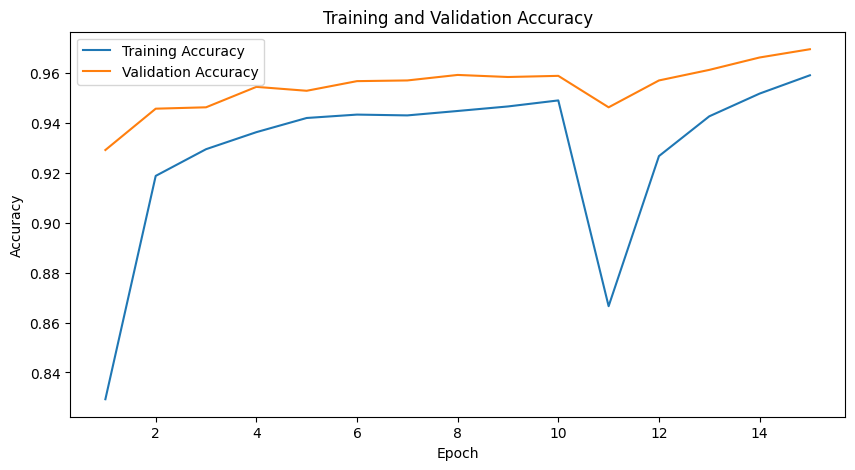

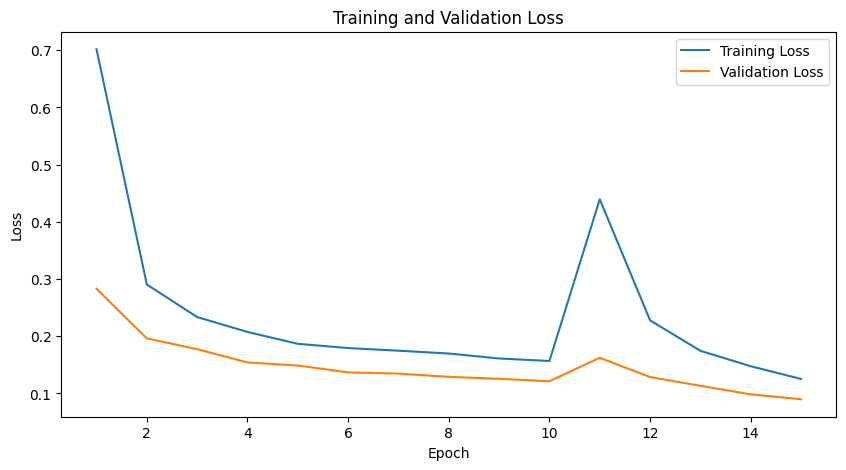

In [32]:
import matplotlib.pyplot as plt

# Combine histories
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

# Accuracy Plot
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 10. Saving the Trained Model

The trained model is saved in Keras format so that it can be reused later for prediction, deployment, or further fine-tuning without retraining.

In [33]:
model.save("plant_disease_efficientnetb0.keras")

print("Model saved successfully!")

Model saved successfully!


## 9. Model Evaluation

The performance of the trained model is evaluated on the validation dataset. The evaluation includes loss and accuracy to measure the model's ability to generalize to unseen data.

### Generating Predictions

To perform a detailed evaluation, predictions are generated for all validation images. These predictions are then used to compute precision, recall, F1-score, and the confusion matrix.

In [34]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

### Classification Report

The classification report provides precision, recall, F1-score, and support for each class. These metrics provide a more detailed understanding of the model's performance than accuracy alone.

In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.89      0.94       126
                                 Apple___Black_rot       0.98      0.99      0.99       125
                          Apple___Cedar_apple_rust       1.00      0.96      0.98        55
                                   Apple___healthy       0.95      0.99      0.97       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.74      0.80       103
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       239
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.95      0.

### Confusion Matrix

The confusion matrix visualizes the model's predictions by comparing the true labels with the predicted labels. It helps identify which classes are correctly classified and which are commonly confused.

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 112    2    0 ...    0    0    0]
 [   0  124    0 ...    0    0    0]
 [   0    0   53 ...    0    0    0]
 ...
 [   0    0    0 ... 1051    0    0]
 [   0    0    0 ...    0   63    1]
 [   0    0    0 ...    0    0  316]]


### Visualizing the Confusion Matrix

The confusion matrix is displayed as a heatmap to make it easier to interpret the classification performance across all plant disease categories.

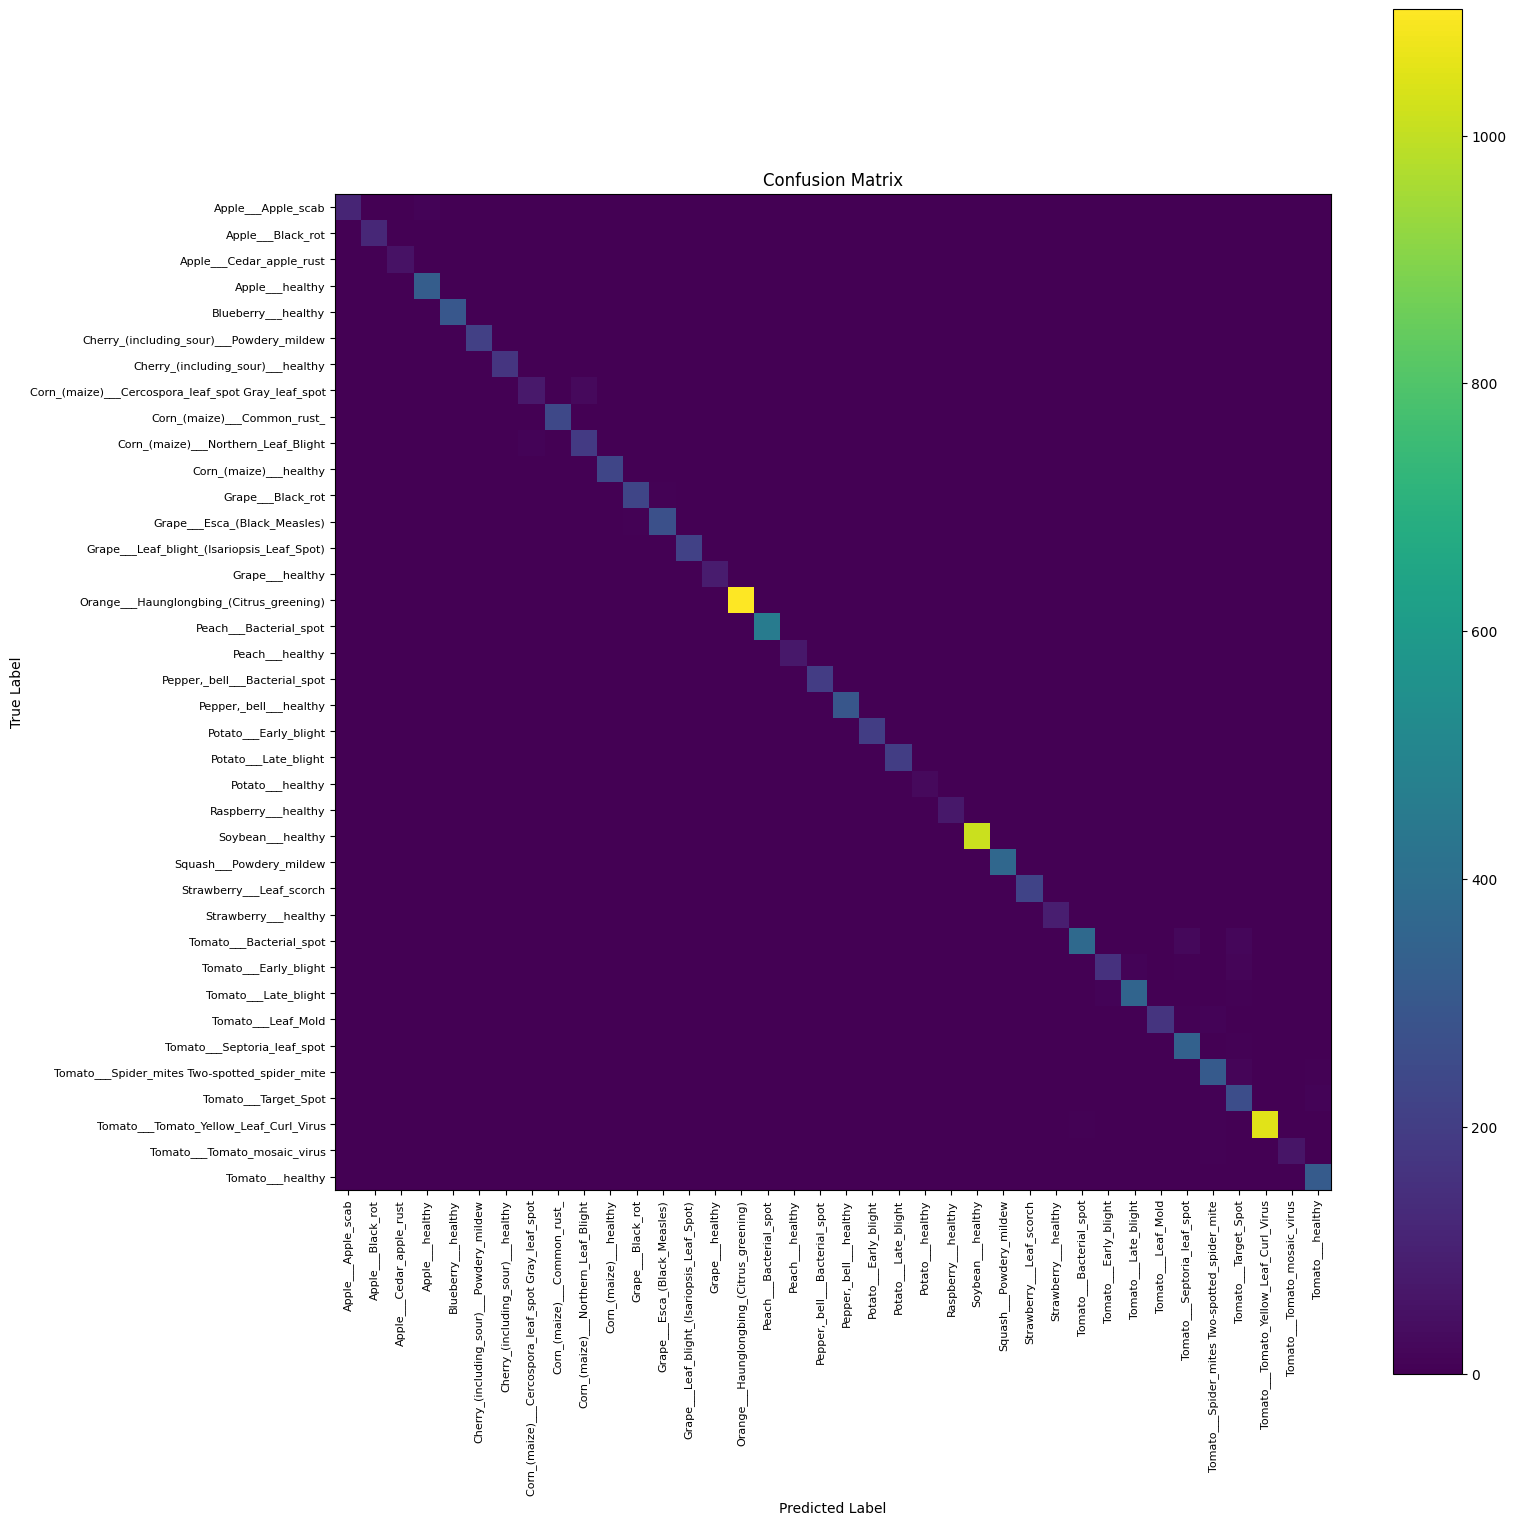

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [39]:
model.save("plant_disease_efficientnetb0.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


## 11. Testing the Model on a Single Image

The trained model is tested on an individual image from the validation dataset to verify its prediction capability on unseen samples.

In [40]:
import random
from tensorflow.keras.preprocessing import image

# Select a random class
random_class = random.choice(class_names)

# Select a random image from that class
img_path = os.path.join(
    val_dir,
    random_class,
    random.choice(os.listdir(os.path.join(val_dir, random_class)))
)

print("Image Path:", img_path)

Image Path: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Orange___Haunglongbing_(Citrus_greening)/5cd802c1-4d11-411e-8dfa-c82037b90353___UF.Citrus_HLB_Lab 0918.JPG


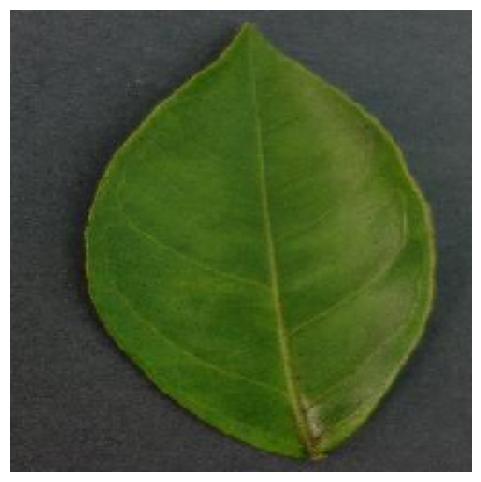

In [41]:
img = image.load_img(img_path, target_size=(224,224))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [42]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

In [43]:
prediction = model.predict(img_array, verbose=0)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Actual Class    :", random_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

Actual Class    : Orange___Haunglongbing_(Citrus_greening)
Predicted Class : Orange___Haunglongbing_(Citrus_greening)
Confidence      : 99.97%


## 12. Conclusion

An EfficientNetB0-based transfer learning model was successfully developed for plant disease classification using the PlantVillage dataset.

The model achieved high validation accuracy after fine-tuning and can accurately classify plant diseases across multiple crop species. The trained model is suitable for deployment in web or mobile applications to assist in automated plant disease diagnosis.